# Uncertainty in an observable
### from the fuzzy spread of a quantum measurement to the zero-point noise on a voltage

Every observable $A$ has, in a state $\psi$, an **expectation** $\langle A\rangle$ and a
**spread** $\Delta A=\sqrt{\langle A^2\rangle-\langle A\rangle^2}$. That spread is not sloppy
equipment -- it is the irreducible fuzziness of the quantity itself. This notebook, driving
`dgs/quantum_operators.py`, shows:

1. repeated measurements of an observable **scatter** with standard deviation $\Delta A$;
2. **concentrating** a wavefunction in position spreads it in momentum -- they are Fourier
   conjugates;
3. the **Heisenberg** floor $\Delta x\,\Delta p\ge\hbar/2$, saturated only by a Gaussian;
4. the same principle on a quantity you read on a meter -- the **voltage** of a quantum $LC$
   circuit has a zero-point uncertainty $\Delta V=\sqrt{\hbar\omega/2C}$, the quantum floor
   under classical $kT\!/C$ thermal noise.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import quantum_operators as qo
hbar = 1.0
x = np.linspace(-40, 40, 8192)
psi = qo.gaussian_packet(x, x0=3.0, sigma=1.5, k0=2.0)
print("<x> = %.3f (x0=3)   Delta_x = %.3f (sigma=1.5)" %
      (qo.expectation_position(psi, x), qo.uncertainty_position(psi, x)))
print("<p> = %.3f (h k0=2) Delta_p = %.3f (h/2sigma=%.3f)" %
      (qo.expectation_momentum(psi, x), qo.uncertainty_momentum(psi, x), 1/(2*1.5)))

<x> = 3.000 (x0=3)   Delta_x = 1.500 (sigma=1.5)
<p> = 2.000 (h k0=2) Delta_p = 0.333 (h/2sigma=0.333)


## 1. An observable is fuzzy: measurements scatter around $\langle A\rangle$

Born's rule says a position measurement returns $x$ with probability $|\psi(x)|^2$. Simulate
20,000 such measurements: the histogram traces $|\psi|^2$, its mean is $\langle x\rangle$, and
its standard deviation is exactly $\Delta x$. The observable has no sharper value to give.

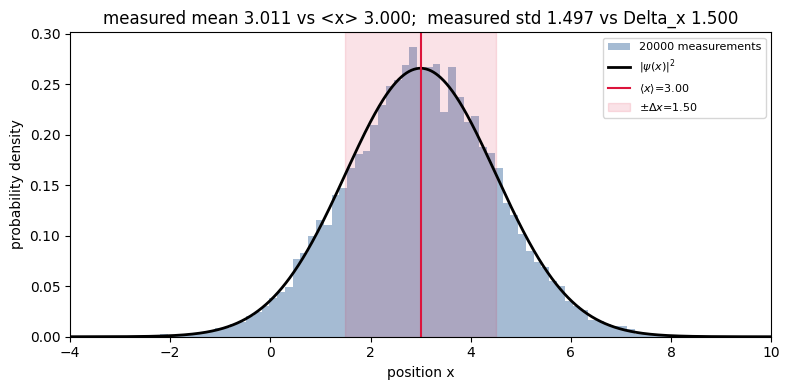

In [2]:
rng = np.random.default_rng(0)
p = np.abs(psi)**2; p = p / p.sum()
samples = rng.choice(x, size=20000, p=p)
xbar, dx = qo.expectation_position(psi, x), qo.uncertainty_position(psi, x)
plt.figure(figsize=(8, 4))
plt.hist(samples, bins=80, density=True, alpha=0.5, color="#4C78A8", label="20000 measurements")
plt.plot(x, p / (x[1]-x[0]), "k", lw=2, label="$|\\psi(x)|^2$")
plt.axvline(xbar, color="crimson", label="$\\langle x\\rangle$=%.2f" % xbar)
plt.axvspan(xbar-dx, xbar+dx, color="crimson", alpha=0.12, label="$\\pm\\Delta x$=%.2f" % dx)
plt.xlim(-4, 10); plt.xlabel("position x"); plt.ylabel("probability density")
plt.title("measured mean %.3f vs <x> %.3f;  measured std %.3f vs Delta_x %.3f"
          % (samples.mean(), xbar, samples.std(), dx))
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. Concentration in $x$ = spreading in $p$

Position and momentum amplitudes are a Fourier-transform pair, so you cannot make both narrow.
A **concentrated** (small $\sigma$) packet is sharp in $x$ but broad in $p$; a wide packet is
the reverse. Watch $\Delta x$ and $\Delta p$ trade off as $\sigma$ changes.

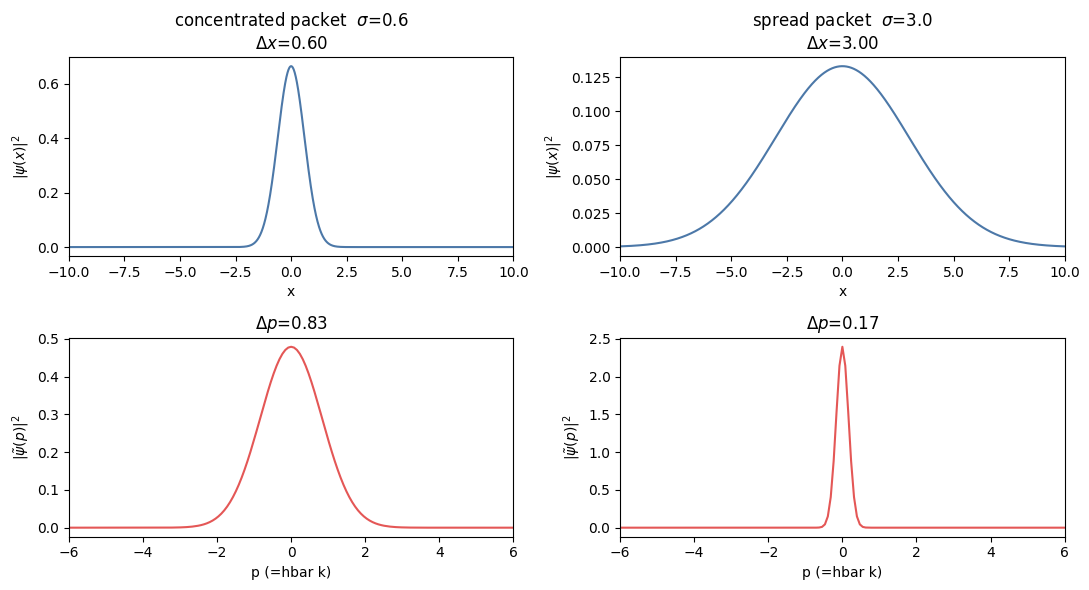

narrow: Dx*Dp = 0.5
wide  : Dx*Dp = 0.5


In [3]:
def momentum_density(psi, x):
    dxs = x[1]-x[0]
    phik = np.fft.fftshift(np.fft.fft(psi)) * dxs
    k = np.fft.fftshift(np.fft.fftfreq(len(x), d=dxs)) * 2*np.pi
    d = np.abs(phik)**2
    return k, d / np.trapezoid(d, k)

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for col, sig in enumerate([0.6, 3.0]):
    ps = qo.gaussian_packet(x, x0=0.0, sigma=sig, k0=0.0)
    dxv, dpv = qo.uncertainty_position(ps, x), qo.uncertainty_momentum(ps, x)
    axes[0, col].plot(x, np.abs(ps)**2, color="#4C78A8")
    axes[0, col].set_xlim(-10, 10); axes[0, col].set_title(
        ("concentrated" if sig < 1 else "spread") + " packet  $\\sigma$=%.1f\n$\\Delta x$=%.2f" % (sig, dxv))
    axes[0, col].set_xlabel("x"); axes[0, col].set_ylabel("$|\\psi(x)|^2$")
    k, dk = momentum_density(ps, x)
    axes[1, col].plot(k, dk, color="#E45756")
    axes[1, col].set_xlim(-6, 6); axes[1, col].set_title("$\\Delta p$=%.2f" % dpv)
    axes[1, col].set_xlabel("p (=hbar k)"); axes[1, col].set_ylabel("$|\\tilde\\psi(p)|^2$")
plt.tight_layout(); plt.show()
print("narrow: Dx*Dp =", round(qo.heisenberg_product(qo.gaussian_packet(x,0,0.6,0),x),4))
print("wide  : Dx*Dp =", round(qo.heisenberg_product(qo.gaussian_packet(x,0,3.0,0),x),4))

## 3. The Heisenberg floor: $\Delta x\,\Delta p\ge\hbar/2$

No matter the width, a Gaussian always gives the **minimum** product $\hbar/2$ -- it sits right
on the floor. Any other shape does worse: a **chirped** Gaussian $e^{-x^2/4\sigma^2}e^{i c x^2}$
carries extra momentum spread from its curved phase, pushing $\Delta x\,\Delta p$ above $\hbar/2$.
The inequality is never violated.

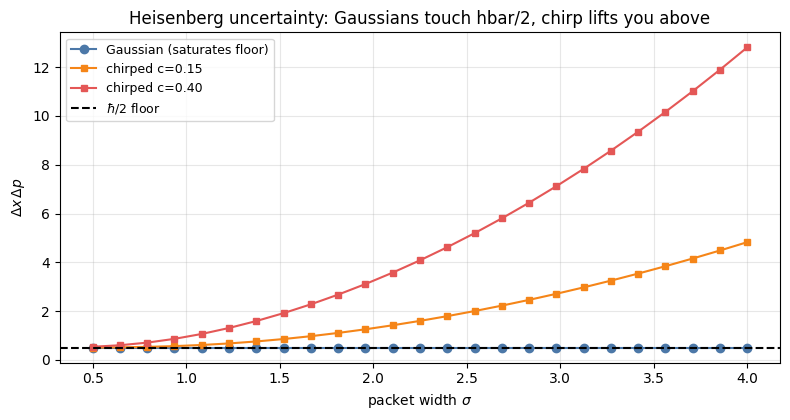

In [4]:
sigmas = np.linspace(0.5, 4.0, 25)
prod_gauss = [qo.heisenberg_product(qo.gaussian_packet(x, 0, s, 0), x) for s in sigmas]
plt.figure(figsize=(8, 4.3))
plt.plot(sigmas, prod_gauss, "o-", color="#4C78A8", label="Gaussian (saturates floor)")
for chirp, c in [(0.15, "#F58518"), (0.4, "#E45756")]:
    prod_chirp = [qo.heisenberg_product(
        qo.gaussian_packet(x, 0, s, 0) * np.exp(1j*chirp*x**2), x) for s in sigmas]
    plt.plot(sigmas, prod_chirp, "s-", ms=4, color=c, label="chirped c=%.2f" % chirp)
plt.axhline(hbar/2, color="k", ls="--", label="$\\hbar/2$ floor")
plt.xlabel("packet width $\\sigma$"); plt.ylabel("$\\Delta x\\,\\Delta p$")
plt.title("Heisenberg uncertainty: Gaussians touch hbar/2, chirp lifts you above")
plt.legend(fontsize=9); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. The uncertainty on an observable you can read: voltage

Take a quantum $LC$ resonator, $H=\dfrac{Q^2}{2C}+\dfrac{\Phi^2}{2L}$. This is a harmonic
oscillator with charge $Q$ and flux $\Phi$ as conjugates, $[\Phi,Q]=i\hbar$, and frequency
$\omega=1/\sqrt{LC}$ -- charge plays the role of momentum, $C$ the role of mass. The **voltage**
$V=Q/C$ is a genuine observable, and it inherits the uncertainty principle: even in the ground
state it fluctuates with

$$\Delta V=\sqrt{\frac{\hbar\omega}{2C}}\qquad(\text{zero-point}).$$

At finite temperature the full spread is
$\Delta V=\sqrt{\dfrac{\hbar\omega}{2C}\coth\dfrac{\hbar\omega}{2kT}}$ -- the *same*
$\tfrac12\hbar\omega\coth(\cdot)$ oscillator energy from the thermal notebooks, mapped onto
volts. Hot: it reduces to the classical $kTC$ noise $\sqrt{kT/C}$ (equipartition, $\tfrac12 kT$
per mode). Cold: it flattens to the quantum floor $\sqrt{\hbar\omega/2C}$ -- the voltage you
literally cannot measure away.

5 GHz, 0.5 pF resonator:  zero-point Delta_V = 1.82 uV
classical kTC at 300 K :  Delta_V = 91.02 uV


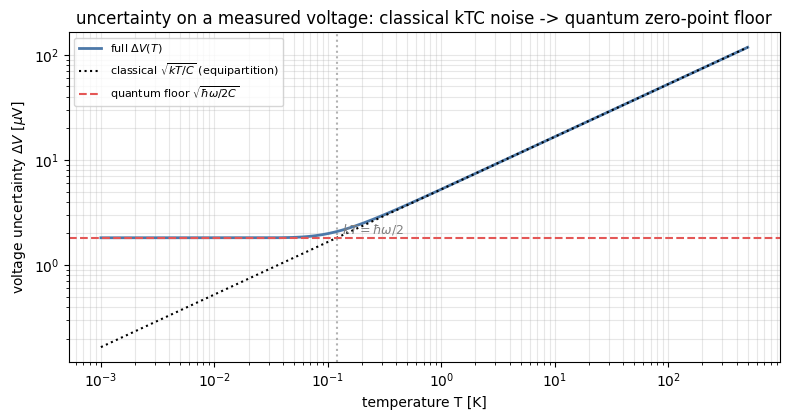

In [5]:
hbar_si, kB = 1.054571817e-34, 1.380649e-23
def dV_total(omega, C, T):
    x = hbar_si*omega/(2*kB*T)
    return np.sqrt((hbar_si*omega/(2*C)) / np.tanh(x))     # coth = 1/tanh
def dV_zpf(omega, C):
    return np.sqrt(hbar_si*omega/(2*C))

f0, C0 = 5e9, 0.5e-12                 # 5 GHz microwave resonator, 0.5 pF
w0 = 2*np.pi*f0
print("5 GHz, 0.5 pF resonator:  zero-point Delta_V = %.2f uV" % (dV_zpf(w0, C0)*1e6))
print("classical kTC at 300 K :  Delta_V = %.2f uV" % (np.sqrt(kB*300/C0)*1e6))

T = np.logspace(-3, 2.7, 200)         # 1 mK to ~500 K
plt.figure(figsize=(8, 4.3))
plt.loglog(T, dV_total(w0, C0, T)*1e6, lw=2, color="#4C78A8", label="full $\\Delta V(T)$")
plt.loglog(T, np.sqrt(kB*T/C0)*1e6, "k:", label="classical $\\sqrt{kT/C}$ (equipartition)")
plt.axhline(dV_zpf(w0, C0)*1e6, color="#E45756", ls="--",
            label="quantum floor $\\sqrt{\\hbar\\omega/2C}$")
plt.axvline(hbar_si*w0/(2*kB), color="gray", ls=":", alpha=0.6)
plt.text(hbar_si*w0/(2*kB)*1.1, 2, "$kT=\\hbar\\omega/2$", color="gray", fontsize=9)
plt.xlabel("temperature T [K]"); plt.ylabel("voltage uncertainty $\\Delta V$ [$\\mu$V]")
plt.title("uncertainty on a measured voltage: classical kTC noise -> quantum zero-point floor")
plt.legend(fontsize=8); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## What we did

* An observable's **spread** $\Delta A=\sqrt{\langle A^2\rangle-\langle A\rangle^2}$ is real:
  simulated measurements scatter with exactly that standard deviation.
* Position and momentum are Fourier conjugates -- **concentrating** one spreads the other.
* $\Delta x\,\Delta p\ge\hbar/2$: Gaussians sit on the floor, a chirped phase lifts you above it.
* The **voltage** of a quantum $LC$ circuit carries a zero-point uncertainty
  $\Delta V=\sqrt{\hbar\omega/2C}$; the finite-$T$ form is the oscillator's
  $\tfrac12\hbar\omega\coth(\hbar\omega/2kT)$ energy in volts, bridging classical $kTC$ noise
  and the quantum floor.

This closes the loop with the thermal thread (`dgs/degrees_of_freedom.py`: $\tfrac12 kT$ per DOF)
and the noise thread (`dgs/flicker_noise.py`: the floors you cannot average away) -- here the
uncertainty principle sets that floor on a quantity you read on a meter.